## Day-Ahead Electricity Price Forecasting
A Probabilistic LASSO-Based Approach for the Germany-Luxembourg Electricity Market



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import QuantileRegressor




In [2]:
df = pd.read_csv('4applicationDSEE_prices_DE_utc.csv')
print(df.info())
#print(df.head())
#print(df.tail())


<class 'pandas.DataFrame'>
RangeIndex: 92519 entries, 0 to 92518
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DateTime     92519 non-null  str    
 1   Price        92519 non-null  float64
 2   Load_DA      92519 non-null  float64
 3   Load_Act     92519 non-null  float64
 4   Solar_DA     92519 non-null  float64
 5   Solar_Act    92519 non-null  float64
 6   WindOn_DA    92519 non-null  float64
 7   WindOn_Act   92519 non-null  float64
 8   WindOff_DA   92519 non-null  float64
 9   WindOff_Act  92519 non-null  float64
 10  Temp_DA      37944 non-null  float64
 11  Temp_Act     92519 non-null  float64
 12  Coal_fM      2755 non-null   float64
 13  Gas_fD       2755 non-null   float64
 14  Gas_fM       2755 non-null   float64
 15  Gas_fQ       2755 non-null   float64
 16  Gas_fY       2755 non-null   float64
 17  Oil_fM       2755 non-null   float64
 18  EUA_fM       2755 non-null   float64
 19  EUR_USD      27

In [3]:
# DateTime index (UTC)
df.index = pd.to_datetime(df['DateTime'], utc=True)
df = df.drop(columns=['DateTime'])
df = df.sort_index()

In [4]:
# Local time features
df['hour_local']    = df.index.tz_convert('Europe/Berlin').hour
df['weekday_local'] = df.index.tz_convert('Europe/Berlin').dayofweek

In [5]:
# EDA   
# Row and Column
print(df.shape)
print(f"Start : {df.index.min()}")
print(f"End   : {df.index.max()}")

(92519, 21)
Start : 2015-01-04 23:00:00+00:00
End   : 2025-07-25 21:00:00+00:00


In [6]:
# Missing Values
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, '%': missing_pct})
print(missing_df[missing_df['count'] > 0])

         count     %
Temp_DA  54575  59.0
Coal_fM  89764  97.0
Gas_fD   89764  97.0
Gas_fM   89764  97.0
Gas_fQ   89764  97.0
Gas_fY   89764  97.0
Oil_fM   89764  97.0
EUA_fM   89764  97.0
EUR_USD  89764  97.0


In [7]:
# Duplicate Timestamps
dups = df.index.duplicated().sum()
missing_ts = pd.date_range(df.index.min(), df.index.max(), 
                            freq='h', tz='UTC')
gaps = missing_ts.difference(df.index)
print(f"Duplicate timestamps : {dups}")
print(f"Missing  timestamps  : {len(gaps)}")

Duplicate timestamps : 0
Missing  timestamps  : 0


In [8]:
# Price Check
print(df['Price'].describe().round(2))
print(f"\nNegative prices: {(df['Price'] < 0).sum()}")

count    92519.00
mean        72.40
std         81.83
min       -500.00
25%         29.92
50%         44.92
75%         88.17
max        936.28
Name: Price, dtype: float64

Negative prices: 2363


In [9]:
# Investigate Temp_DA 
first_temp = df['Temp_DA'].first_valid_index()
last_temp  = df['Temp_DA'].last_valid_index()
print(f"Temp_DA first valid : {first_temp}")
print(f"Temp_DA last valid  : {last_temp}")
print(f"Rows after first_temp: {len(df[df.index >= first_temp]):,}")
temp_after = df.loc[df.index >= first_temp, 'Temp_DA']
print(f"NaN in Temp_DA after first valid: {temp_after.isna().sum()}")



Temp_DA first valid : 2021-01-11 23:00:00+00:00
Temp_DA last valid  : 2025-07-25 21:00:00+00:00
Rows after first_temp: 39,743
NaN in Temp_DA after first valid: 1799


In [10]:
# Data Cleaning
# Drop Act columns + Temp_DA
# Using these "Actual" columns in training data would be like "cheating" .This is called Data Leakage .
cols_to_drop = ['Load_Act', 'Solar_Act', 'WindOn_Act', 
                'WindOff_Act', 'Temp_Act', 'Temp_DA']
df = df.drop(columns=cols_to_drop)

# ffill Commodities 
commodity_cols = ['Coal_fM', 'Gas_fD', 'Gas_fM', 'Gas_fQ', 
                  'Gas_fY', 'Oil_fM', 'EUA_fM', 'EUR_USD']
df[commodity_cols] = df[commodity_cols].ffill()

# Check remaining NaNs 
print("\nRemaining NaNs after ffill:")
nan_check = df.isna().sum()
print(nan_check[nan_check > 0])

# Residual Load
df['Residual_Load'] = (df['Load_DA'] 
                       - df['Solar_DA'] 
                       - df['WindOn_DA'] 
                       - df['WindOff_DA'])

# Final check
print("\nFinal shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\n NaN left:", df.isna().sum().sum())


Remaining NaNs after ffill:
Series([], dtype: int64)

Final shape: (92519, 16)

Columns: ['Price', 'Load_DA', 'Solar_DA', 'WindOn_DA', 'WindOff_DA', 'Coal_fM', 'Gas_fD', 'Gas_fM', 'Gas_fQ', 'Gas_fY', 'Oil_fM', 'EUA_fM', 'EUR_USD', 'hour_local', 'weekday_local', 'Residual_Load']

 NaN left: 0


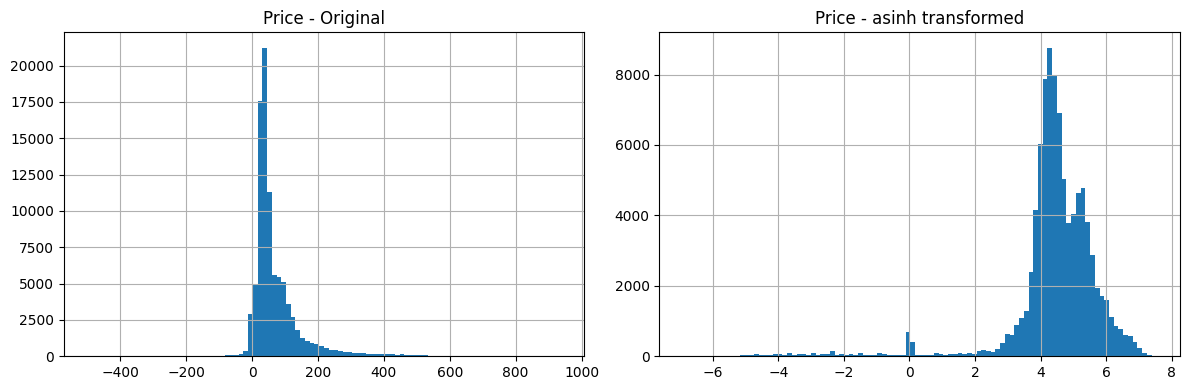

In [11]:
# Plot Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Price'].hist(bins=100, ax=axes[0])
axes[0].set_title('Price - Original')

# asinh transformed
np.arcsinh(df['Price']).hist(bins=100, ax=axes[1])
axes[1].set_title('Price - asinh transformed')

plt.tight_layout()
plt.show()

In [12]:
# create New Features
# asinh transformation 
df['Price_asinh'] = np.arcsinh(df['Price'])

# Price lags
df['Price_lag1']  = df['Price_asinh'].shift(1)  
df['Price_lag24']  = df['Price_asinh'].shift(24)
df['Price_lag48']  = df['Price_asinh'].shift(48)
df['Price_lag168'] = df['Price_asinh'].shift(168)

# One-hot encoding
hour_dummies    = pd.get_dummies(df['hour_local'], 
                                  prefix='h', 
                                  drop_first=True)
weekday_dummies = pd.get_dummies(df['weekday_local'], 
                                  prefix='wd', 
                                  drop_first=True)

df = pd.concat([df, hour_dummies, weekday_dummies], axis=1)

# Drop original hour/weekday columns
df = df.drop(columns=['hour_local', 'weekday_local'])

# Drop first 168 rows (NaN from lag168)
df = df.dropna()

# Final check
print("Shape after feature engineering:", df.shape)
print("\nNaN remaining:", df.isna().sum().sum())
print("\nNew columns added:")
new_cols = ['Price_asinh', 'Price_lag24', 
            'Price_lag48', 'Price_lag168']
print(df[new_cols].head(3))




Shape after feature engineering: (92351, 48)

NaN remaining: 0

New columns added:
                           Price_asinh  Price_lag24  Price_lag48  Price_lag168
DateTime                                                                      
2015-01-11 23:00:00+00:00     2.926040     0.049979     3.533080      3.800027
2015-01-12 00:00:00+00:00     1.776515    -1.470151     3.254189      3.580399
2015-01-12 01:00:00+00:00     0.089879    -2.121052     3.311872      3.413552


In [13]:
# Train / Validation / Test Split
train_end = '2022-12-31 23:00:00+00:00'
val_end   = '2023-12-31 23:00:00+00:00'

train = df[df.index <= train_end]
val   = df[(df.index > train_end) & (df.index <= val_end)]
test  = df[df.index > val_end]

print("Split sizes:")
print(f"Train : {len(train):,} rows | {train.index.min().date()} → {train.index.max().date()}")
print(f"Val   : {len(val):,} rows | {val.index.min().date()} → {val.index.max().date()}")
print(f"Test  : {len(test):,} rows | {test.index.min().date()} → {test.index.max().date()}")
print(f"\nTotal : {len(train)+len(val)+len(test):,} rows")
print(f"\nTrain % : {len(train)/(len(train)+len(val)+len(test))*100:.1f}%")
print(f"Val   % : {len(val)/(len(train)+len(val)+len(test))*100:.1f}%")
print(f"Test  % : {len(test)/(len(train)+len(val)+len(test))*100:.1f}%")


Split sizes:
Train : 69,865 rows | 2015-01-11 → 2022-12-31
Val   : 8,760 rows | 2023-01-01 → 2023-12-31
Test  : 13,726 rows | 2024-01-01 → 2025-07-25

Total : 92,351 rows

Train % : 75.7%
Val   % : 9.5%
Test  % : 14.9%


In [14]:
# Define features and target
target = 'Price_asinh'
# exclude Price and Price_asinh columns from features
exclude = ['Price', 'Price_asinh']
features = [col for col in df.columns if col not in exclude]


# Create X, y for each split
X_train = train[features]
y_train = train[target]

X_val = val[features]
y_val = val[target]

X_test = test[features]
y_test = test[target]

print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

# Scale X (fit ONLY on train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("\nScaler fit on train only ✓")
print(f"Train mean (first feature): {scaler.mean_[0]:.4f}")

# LassoCV (tunes lambda)
tscv = TimeSeriesSplit(n_splits=5)
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 2, 50),
    cv=tscv,
    max_iter=10000,
    random_state=42,
    n_jobs=-1
)
print("\nFitting LassoCV:")
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best lambda (alpha): {lasso_cv.alpha_:.6f}")
print(f"Non-zero features  : {np.sum(lasso_cv.coef_ != 0)} / {len(features)}")


X_train shape: (69865, 46)
X_val shape  : (8760, 46)
X_test shape : (13726, 46)



Scaler fit on train only ✓
Train mean (first feature): 55.1097

Fitting LassoCV:
Best lambda (alpha): 0.000409
Non-zero features  : 40 / 46


In [15]:
# Feature importance
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': lasso_cv.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("SELECTED FEATURES:")
selected = coef_df[coef_df['coefficient'] != 0]
print(selected.to_string())

print("\nREMOVED FEATURES:")
removed = coef_df[coef_df['coefficient'] == 0]
print(removed['feature'].tolist())

SELECTED FEATURES:
          feature  coefficient
13     Price_lag1     1.122700
12  Residual_Load     0.066556
33           h_17     0.063068
23            h_7     0.048151
22            h_6     0.047645
32           h_16     0.045239
34           h_18     0.042037
10         EUA_fM     0.041555
21            h_5     0.038581
31           h_15     0.036189
2       WindOn_DA    -0.035377
24            h_8     0.031549
1        Solar_DA    -0.023610
35           h_19     0.023291
5          Gas_fD     0.023102
20            h_4     0.020808
9          Oil_fM     0.017881
39           h_23    -0.017512
27           h_11     0.016855
16   Price_lag168     0.014811
3      WindOff_DA     0.014357
14    Price_lag24     0.012888
25            h_9     0.012438
30           h_14     0.010747
38           h_22     0.009802
19            h_3     0.006821
45           wd_6    -0.006073
28           h_12     0.005992
11        EUR_USD     0.005383
4         Coal_fM     0.005343
26           h_10   

In [16]:
# Define predictions and true values
y_val_pred  = np.sinh(lasso_cv.predict(X_val_scaled))
y_test_pred = np.sinh(lasso_cv.predict(X_test_scaled))
y_val_true  = np.sinh(y_val.values)
y_test_true = np.sinh(y_test.values)


In [17]:
# Compare with/without lag1
features_wo_lag1 = [f for f in features if f != 'Price_lag1']

scaler_wo = StandardScaler()
X_train_wo = scaler_wo.fit_transform(X_train[features_wo_lag1])
X_val_wo   = scaler_wo.transform(X_val[features_wo_lag1])

tscv = TimeSeriesSplit(n_splits=5)
lasso_wo = LassoCV(
    alphas=np.logspace(-4, 2, 50),
    cv=tscv,
    max_iter=10000,
    random_state=42,
    n_jobs=-1
)

lasso_wo.fit(X_train_wo, y_train)

y_val_pred_wo = np.sinh(lasso_wo.predict(X_val_wo))

def print_metrics(true, pred, name):
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

print("\n COMPARISON :")
print("WITH lag1:")
print_metrics(y_val_true, y_val_pred, "  Validation")
print("\nWITHOUT lag1:")
print_metrics(y_val_true, y_val_pred_wo, "  Validation")


 COMPARISON :
WITH lag1:
  Validation | MAE: 10.58 | RMSE: 16.21

WITHOUT lag1:
  Validation | MAE: 36.79 | RMSE: 54.17


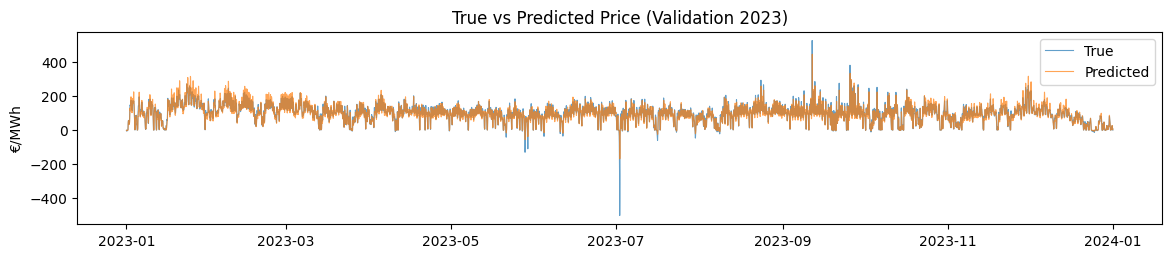

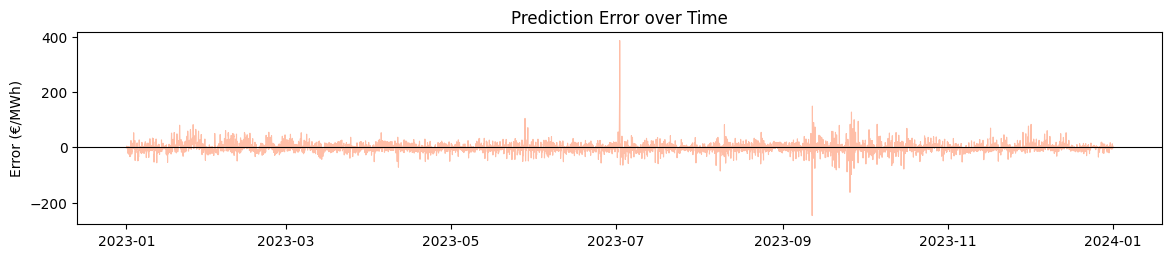

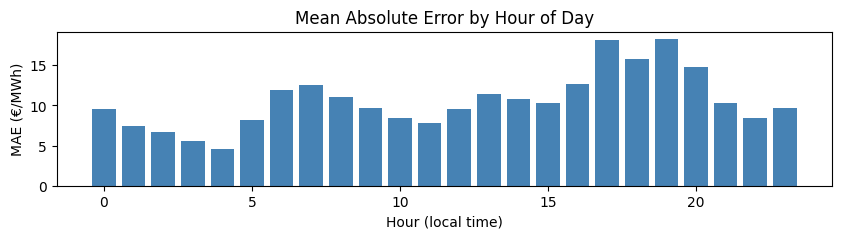

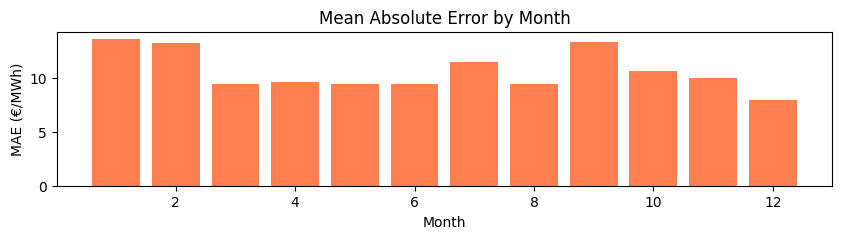

In [18]:
# Error Analysis

error_df = pd.DataFrame({
    'true'      : y_val_true,
    'pred'      : y_val_pred,
    'error'     : y_val_pred - y_val_true,
    'abs_error' : np.abs(y_val_pred - y_val_true)
}, index=val.index)

error_df['hour']    = error_df.index.tz_convert('Europe/Berlin').hour
error_df['weekday'] = error_df.index.tz_convert('Europe/Berlin').dayofweek
error_df['month']   = error_df.index.tz_convert('Europe/Berlin').month


# True vs Predicted
plt.figure(figsize=(14, 2.5))
plt.plot(error_df.index, error_df['true'], label='True', alpha=0.7, linewidth=0.8)
plt.plot(error_df.index, error_df['pred'], label='Predicted', alpha=0.7, linewidth=0.8)
plt.title('True vs Predicted Price (Validation 2023)')
plt.legend()
plt.ylabel('€/MWh')
plt.savefig('1_true_vs_pred.png', dpi=300, bbox_inches='tight')
plt.show()

# Error over Time 
plt.figure(figsize=(14, 2.5))
plt.plot(error_df.index, error_df['error'], color='coral', alpha=0.5, linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Prediction Error over Time')
plt.ylabel('Error (€/MWh)')
plt.savefig('2_error_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

# MAE by Hour
plt.figure(figsize=(10, 2))
error_by_hour = error_df.groupby('hour')['abs_error'].mean()
plt.bar(error_by_hour.index, error_by_hour.values, color='steelblue')
plt.title('Mean Absolute Error by Hour of Day')
plt.xlabel('Hour (local time)')
plt.ylabel('MAE (€/MWh)')
plt.savefig('3_mae_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

# MAE by Month 
plt.figure(figsize=(10, 2))
error_by_month = error_df.groupby('month')['abs_error'].mean()
plt.bar(error_by_month.index, error_by_month.values, color='coral')
plt.title('Mean Absolute Error by Month')
plt.xlabel('Month')
plt.ylabel('MAE (€/MWh)')
plt.savefig('4_mae_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Probabilistic Forecast (Quantile Regression)
quantiles = [0.1, 0.5, 0.9]
alphas = np.logspace(-4, -1, 6)

print("Alphas:", alphas)

def pinball_loss(true, pred, q):
    errors = true - pred
    return np.mean(np.where(errors >= 0, q * errors, (q - 1) * errors))

best_alpha_q10 = None
best_loss=np.inf
for a in alphas:
    qr = QuantileRegressor(quantile=0.1, alpha=a, solver='highs-ds')
    qr.fit(X_train_scaled, y_train)
    pred=np.sinh(qr.predict(X_val_scaled))
    loss = pinball_loss(y_val_true, pred, 0.1)
    print(f"alpha: {a:.5f} | Loss: {loss:.3f}")
    if loss < best_loss:
        best_loss = loss
        best_alpha_q10 = a

print("\nBest alpha for q10:", best_alpha_q10)

best_alpha_q90 = None
best_loss=np.inf
for a in alphas:
    qr = QuantileRegressor(quantile=0.9, alpha=a, solver='highs-ds')
    qr.fit(X_train_scaled, y_train)
    pred=np.sinh(qr.predict(X_val_scaled))
    loss = pinball_loss(y_val_true, pred, 0.9)
    print(f"alpha: {a:.5f} | Loss: {loss:.3f}")
    if loss < best_loss:
        best_loss = loss
        best_alpha_q90 = a

print("\nBest alpha for q90:", best_alpha_q90)




Alphas: [0.0001     0.00039811 0.00158489 0.00630957 0.02511886 0.1       ]
alpha: 0.00010 | Loss: 2.500
alpha: 0.00040 | Loss: 2.415
alpha: 0.00158 | Loss: 2.343
alpha: 0.00631 | Loss: 2.317
alpha: 0.02512 | Loss: 2.516
alpha: 0.10000 | Loss: 3.133

Best alpha for q10: 0.00630957344480193
alpha: 0.00010 | Loss: 2.546
alpha: 0.00040 | Loss: 2.500
alpha: 0.00158 | Loss: 2.366
alpha: 0.00631 | Loss: 2.364
alpha: 0.02512 | Loss: 2.641
alpha: 0.10000 | Loss: 4.230

Best alpha for q90: 0.00630957344480193


In [20]:
# Train final quantile regressors with best alphas and predict on validation set
qr_low = QuantileRegressor(quantile=0.1, alpha=best_alpha_q10, solver='highs-ds')
qr_med  = QuantileRegressor(quantile=0.5, alpha=lasso_cv.alpha_,  solver='highs-ds')
qr_high = QuantileRegressor(quantile=0.9, alpha=best_alpha_q90, solver='highs-ds')

qr_low.fit(X_train_scaled, y_train)
qr_med.fit(X_train_scaled, y_train)
qr_high.fit(X_train_scaled, y_train)

q10 = np.sinh(qr_low.predict(X_val_scaled))
q50 = np.sinh(qr_med.predict(X_val_scaled))
q90 = np.sinh(qr_high.predict(X_val_scaled))


val_loss_q50 = pinball_loss(y_val_true, q50, 0.5)

print(f"Final Pinball Loss (q50): {val_loss_q50:.2f}")
print(f"Median-based MAE: {val_loss_q50 * 2:.2f}")


Final Pinball Loss (q50): 4.06
Median-based MAE: 8.13


In [21]:
# Evaluate coverage
coverage = np.mean((y_val_true >= q10) & (y_val_true <= q90))
print("Coverage:", coverage)

Coverage: 0.7488584474885844


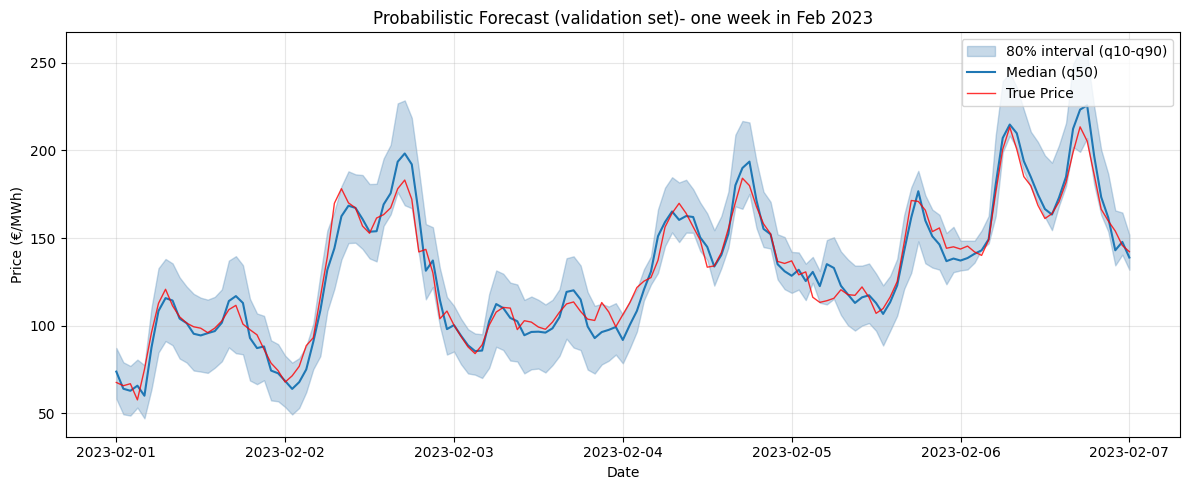

In [22]:
# Plot probabilistic forecast for a week in validation set
mask_val = (val.index >= '2023-02-01') & (val.index <= '2023-02-07')

plt.figure(figsize=(12,5))

plt.fill_between(val.index[mask_val], 
                 q10[mask_val], 
                 q90[mask_val], 
                 alpha=0.3, color='steelblue', label='80% interval (q10-q90)')

plt.plot(val.index[mask_val], 
         q50[mask_val], 
         label='Median (q50)', linewidth=1.5)

plt.plot(val.index[mask_val], 
         y_val_true[mask_val], 
         label='True Price', color='red', linewidth=1, alpha=0.8)

plt.title("Probabilistic Forecast (validation set)- one week in Feb 2023")
plt.ylabel("Price (€/MWh)")
plt.xlabel("Date")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()

# ذخیره عکس برای اسلاید
plt.savefig('val_probabilistic_plot.png', dpi=300)
plt.show()

In [23]:
# Final evaluation on test set
# Combine train + validation
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

# Refit on combined data with best alpha
qr_low = QuantileRegressor(
quantile=0.1,
alpha=best_alpha_q10,
solver='highs-ds'
)

qr_med = QuantileRegressor(
quantile=0.5,
alpha=lasso_cv.alpha_,
solver='highs-ds'
)

qr_high = QuantileRegressor(
quantile=0.9,
alpha=best_alpha_q90,
solver='highs-ds'
)

# fit on combined train+val
qr_low.fit(X_trainval, y_trainval)
qr_med.fit(X_trainval, y_trainval)
qr_high.fit(X_trainval, y_trainval)

,"quantile quantile: float, default=0.5The quantile that the model tries to predict. It must be strictlybetween 0 and 1. If 0.5 (default), the model predicts the 50%quantile, i.e. the median.",0.9
,"alpha alpha: float, default=1.0Regularization constant that multiplies the L1 penalty term.",np.float64(0....0957344480193)
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit the intercept.",True
,"solver solver: {'highs-ds', 'highs-ipm', 'highs', 'interior-point', 'revised simplex'}, default='highs'Method used by :func:`scipy.optimize.linprog` to solve the linearprogramming formulation.It is recommended to use the highs methods becausethey are the fastest ones. Solvers ""highs-ds"", ""highs-ipm"" and ""highs""support sparse input data and, in fact, always convert to sparse csc.From `scipy>=1.11.0`, ""interior-point"" is not available anymore... versionchanged:: 1.4 The default of `solver` changed to `""highs""` in version 1.4.",'highs-ds'
,"solver_options solver_options: dict, default=NoneAdditional parameters passed to :func:`scipy.optimize.linprog` asoptions. If `None` and if `solver='interior-point'`, then`{""lstsq"": True}` is passed to :func:`scipy.optimize.linprog` for thesake of stability.",None


In [24]:
# Predict on test set
q10_test = np.sinh(qr_low.predict(X_test_scaled))
q50_test = np.sinh(qr_med.predict(X_test_scaled))
q90_test = np.sinh(qr_high.predict(X_test_scaled))

In [25]:
# Ensure q10 <= q50 <= q90
preds_matrix = np.column_stack([q10_test, q50_test, q90_test])
preds_sorted = np.sort(preds_matrix, axis=1)
q10_test = preds_sorted[:, 0]
q50_test = preds_sorted[:, 1]
q90_test = preds_sorted[:, 2]

In [26]:
# Evaluate Test coverage
y_test_true = np.sinh(y_test.values)
coverage_test = np.mean((y_test_true >= q10_test) & (y_test_true <= q90_test))
print("Test Coverage:", coverage_test)

# Evaluate MAE and RMSE on test set
mae_test = mean_absolute_error(y_test_true, q50_test)
print("Test MAE:", mae_test)
rmse_test = np.sqrt(mean_squared_error(y_test_true, q50_test))
print("Test RMSE:", rmse_test)


Test Coverage: 0.5644761765991549
Test MAE: 9.970239309005553
Test RMSE: 18.456575267920105


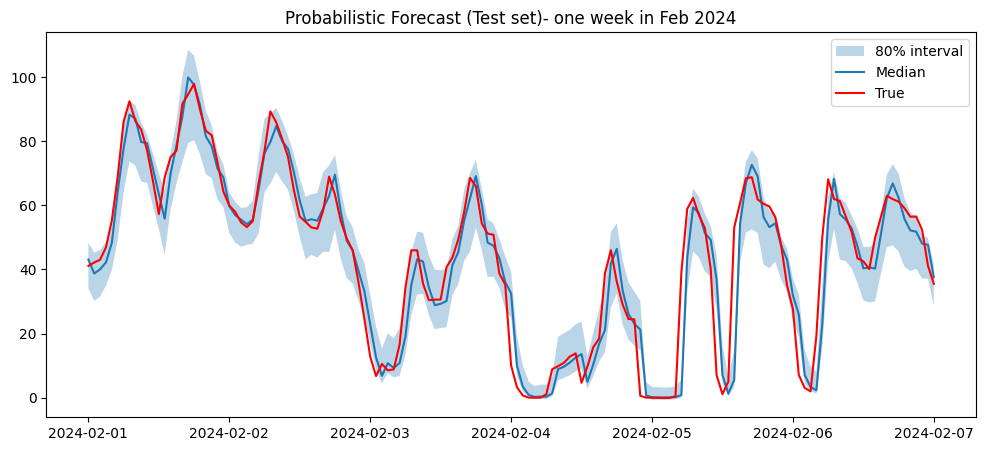

In [27]:
# Plot probabilistic forecast for a week in test set
mask = (test.index >= '2024-02-01') & (test.index <= '2024-02-07')

plt.figure(figsize=(12,5))

plt.fill_between(test.index[mask],
q10_test[mask],
q90_test[mask],
alpha=0.3, label='80% interval')

plt.plot(test.index[mask],
q50_test[mask],
label='Median')

plt.plot(test.index[mask],
y_test_true[mask],
label='True', color='red')

plt.legend()
plt.title("Probabilistic Forecast (Test set)- one week in Feb 2024")
plt.show()